Model dataset: 26,133 rows
Train: 17,373 rows | Test: 8,760 rows

Baseline (lag-168)  MAE: 4,749 MW  RMSE: 6,676 MW
Linear Regression   MAE: 2,167 MW  RMSE: 3,014 MW
XGBoost + Weather   MAE: 2,077 MW  RMSE: 2,827 MW

--- Final Results ---
            Model MAE (MW) RMSE (MW)
 Lag-168 Baseline    4,749     6,676
Linear Regression    2,167     3,014
XGBoost + Weather    2,077     2,827


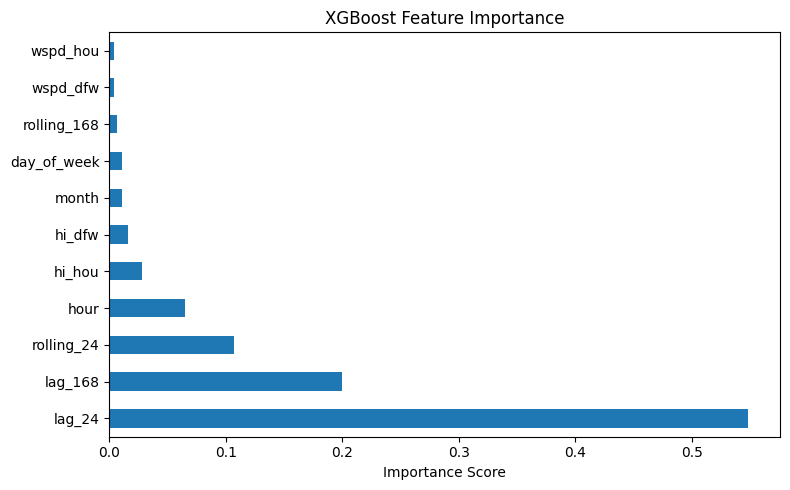

Saved: reports/feature_importance.png


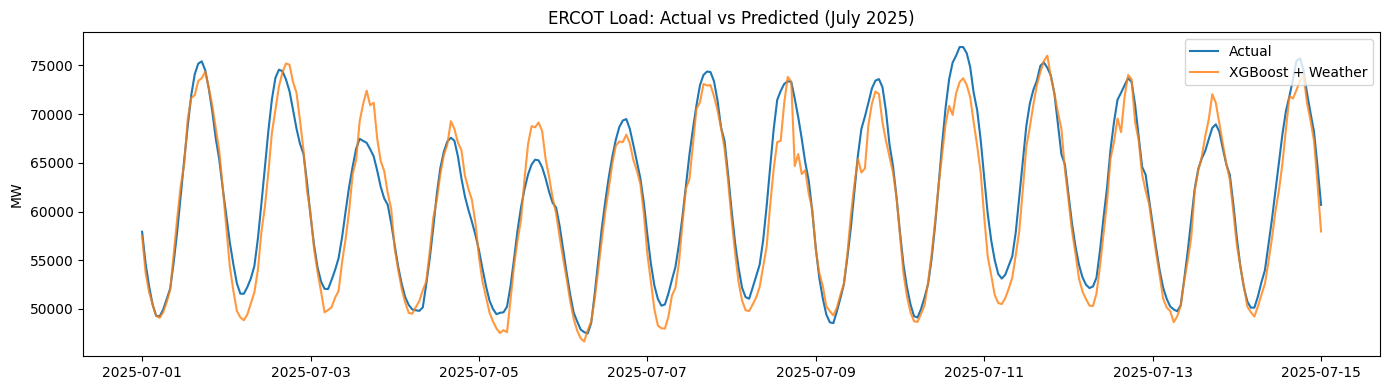

Saved: reports/actual_vs_predicted.png


In [15]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os

# -- 1. LOAD DATA
df = pd.read_csv("../data/processed/ercot_load_hourly_2023_2025.csv")
df["dt"] = pd.to_datetime(df["dt"])
df = df.sort_values("dt").reset_index(drop=True)

# -- 2. FEATURE ENGINEERING
df["lag_24"]      = df["load_mw"].shift(24)
df["lag_168"]     = df["load_mw"].shift(168)
df["hour"]        = df["dt"].dt.hour
df["day_of_week"] = df["dt"].dt.dayofweek
df["month"]       = df["dt"].dt.month
df["rolling_24"]  = df["load_mw"].shift(1).rolling(24).mean()
df["rolling_168"] = df["load_mw"].shift(1).rolling(168).mean()
df_model = df.dropna().copy()
print(f"Model dataset: {df_model.shape[0]:,} rows")

# -- 3. FETCH WEATHER
def fetch_weather(lat, lon, start, end, suffix):
    r = requests.get("https://archive-api.open-meteo.com/v1/archive", params={
        "latitude": lat,
        "longitude": lon,
        "start_date": start,
        "end_date": end,
        "hourly": "temperature_2m,relativehumidity_2m,windspeed_10m",
        "timezone": "America/Chicago",
        "temperature_unit": "fahrenheit"
    })
    r.raise_for_status()
    d = r.json()
    return pd.DataFrame({
        "dt":               pd.to_datetime(d["hourly"]["time"]),
        f"temp_f{suffix}":  d["hourly"]["temperature_2m"],
        f"rhum{suffix}":    d["hourly"]["relativehumidity_2m"],
        f"wspd{suffix}":    d["hourly"]["windspeed_10m"],
    })

dallas  = fetch_weather(32.8998, -97.0403, "2023-01-01", "2025-07-15", "_dfw")
houston = fetch_weather(29.7604, -95.3698, "2023-01-01", "2025-07-15", "_hou")

df_model = df_model.merge(dallas,  on="dt", how="left")
df_model = df_model.merge(houston, on="dt", how="left")
df_model = df_model.ffill()

def heat_index(T, R):
    return (
        -42.379
        + 2.04901523  * T
        + 10.14333127 * R
        - 0.22475541  * T * R
        - 0.00683783  * T**2
        - 0.05481717  * R**2
        + 0.00122874  * T**2 * R
        + 0.00085282  * T * R**2
        - 0.00000199  * T**2 * R**2
    )

df_model["hi_dfw"] = heat_index(df_model["temp_f_dfw"], df_model["rhum_dfw"])
df_model["hi_hou"] = heat_index(df_model["temp_f_hou"], df_model["rhum_hou"])

# -- 4. TRAIN / TEST SPLIT
train = df_model[df_model["dt"] < "2025-01-01"]
test  = df_model[df_model["dt"] >= "2025-01-01"]
print(f"Train: {train.shape[0]:,} rows | Test: {test.shape[0]:,} rows")

# -- 5. BASELINE: Lag-168
mae_baseline  = mean_absolute_error(test["load_mw"], test["lag_168"])
rmse_baseline = np.sqrt(mean_squared_error(test["load_mw"], test["lag_168"]))
print(f"\nBaseline (lag-168)  MAE: {mae_baseline:,.0f} MW  RMSE: {rmse_baseline:,.0f} MW")

# -- 6. LINEAR REGRESSION
lr_features = ["lag_24", "lag_168", "hour", "day_of_week", "rolling_24", "rolling_168"]
lr = LinearRegression()
lr.fit(train[lr_features], train["load_mw"])
preds_lr = lr.predict(test[lr_features])
mae_lr  = mean_absolute_error(test["load_mw"], preds_lr)
rmse_lr = np.sqrt(mean_squared_error(test["load_mw"], preds_lr))
print(f"Linear Regression   MAE: {mae_lr:,.0f} MW  RMSE: {rmse_lr:,.0f} MW")

# -- 7. XGBOOST + WEATHER
features = [
    "lag_24", "lag_168", "hour", "day_of_week", "month",
    "rolling_24", "rolling_168",
    "hi_dfw", "hi_hou", "wspd_dfw", "wspd_hou"
]

xgb = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(train[features], train["load_mw"])
preds_xgb = xgb.predict(test[features])
mae_xgb  = mean_absolute_error(test["load_mw"], preds_xgb)
rmse_xgb = np.sqrt(mean_squared_error(test["load_mw"], preds_xgb))
print(f"XGBoost + Weather   MAE: {mae_xgb:,.0f} MW  RMSE: {rmse_xgb:,.0f} MW")

# -- 8. RESULTS SUMMARY
print("\n--- Final Results ---")
results = pd.DataFrame({
    "Model":     ["Lag-168 Baseline", "Linear Regression", "XGBoost + Weather"],
    "MAE (MW)":  [f"{mae_baseline:,.0f}", f"{mae_lr:,.0f}", f"{mae_xgb:,.0f}"],
    "RMSE (MW)": [f"{rmse_baseline:,.0f}", f"{rmse_lr:,.0f}", f"{rmse_xgb:,.0f}"],
})
print(results.to_string(index=False))

# -- 9. FEATURE IMPORTANCE PLOT
os.makedirs("../reports", exist_ok=True)
importance = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)
importance.plot(kind="barh", figsize=(8, 5), title="XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("../reports/feature_importance.png", dpi=150)
plt.show()
print("Saved: reports/feature_importance.png")

# -- 10. ACTUAL VS PREDICTED PLOT
plot_df = test.copy()
plot_df["pred_xgb"] = preds_xgb
slice_df = plot_df[(plot_df["dt"] >= "2025-07-01") & (plot_df["dt"] <= "2025-07-15")]

plt.figure(figsize=(14, 4))
plt.plot(slice_df["dt"], slice_df["load_mw"],  label="Actual")
plt.plot(slice_df["dt"], slice_df["pred_xgb"], label="XGBoost + Weather", alpha=0.8)
plt.legend()
plt.title("ERCOT Load: Actual vs Predicted (July 2025)")
plt.ylabel("MW")
plt.tight_layout()
plt.savefig("../reports/actual_vs_predicted.png", dpi=150)
plt.show()
print("Saved: reports/actual_vs_predicted.png")